In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from groq import RateLimitError, APIError, APIConnectionError
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from functools import partial
from prompts import SYSTEM_PROMPT
from tools import calculator, rag_tool, web_search
from llm_router import invoke_with_fallback, MODEL_CHAIN
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from chat_app_backend_rag import llm_structured
import tqdm as notebook_tqdm


In [3]:

load_dotenv()

tools = [rag_tool, calculator, web_search]

# Plain (non-tool-bound) model used for cheap one-off calls like title generation.
llm = MODEL_CHAIN[0]


def get_summary_for_chatHead(user: str) -> str:
    prompt = f"""Generate a short, descriptive title for this conversation based on the user's message below.
                Rules:
                - Maximum 5 words
                - No quotation marks, punctuation, or trailing periods
                - Capture the core topic or intent, not a generic summary
                - Do not include phrases like "Chat about" or "Conversation on"
                - Return ONLY the title text, nothing else
                User's message:{user}"""

    response = llm.invoke(prompt)
    return response.content



In [32]:
MAX_RETRIES = 2

class AnswerCheck(BaseModel):
    is_relevant: bool = Field(description="True if the answer actually addresses the user's question")
    reason: str = Field(description="Brief explanation of the judgment")


class MessageState(TypedDict):
    message: Annotated[list[BaseMessage], add_messages]
    kb_id: str
    retry_count: int


def _check_answer(question: str, answer: str) -> AnswerCheck:
    check_prompt = PromptTemplate(
        template="""
            You are checking whether an AI-generated answer actually addresses the user's question.

            Question: {question}
            Answer: {answer}

            Judge whether the answer is relevant and actually responds to the question.
            Be strict but fair.
        """,
        input_variables=['question', 'answer']
    )
    prompt = check_prompt.format(question=question, answer=answer)
    checker_llm = llm_structured.with_structured_output(AnswerCheck)
    return checker_llm.invoke(prompt)


def check_answer_node(state: MessageState):
    message = list(state['message'])
    last_ai = message[-1]
    last_human = next(m for m in reversed(message) if isinstance(m, HumanMessage))
    retry_count = state.get('retry_count', 0)

    try:
        check = _check_answer(last_human.content, last_ai.content)
    except Exception:
        return {'message': [], 'retry_count': 0}  # fail open, don't loop

    if check.is_relevant:
        return {'message': [], 'retry_count': 0}

    if retry_count >= MAX_RETRIES:
        return {
            'message': [AIMessage(
                id=last_ai.id,
                content="I wasn't able to generate a reliable answer to that. "
                        "Could you try rephrasing your question?"
            )],
            'retry_count': 0
        }
    return {
        'message': [HumanMessage(
            content=f"Your previous answer didn't address the question "
                    f"(reason: {check.reason}). Please answer this again: {last_human.content}"
        )],
        'retry_count': retry_count + 1
    }


def route_after_check(state: MessageState) -> str:
    last = state['message'][-1] if state['message'] else None
    return "retry" if isinstance(last, HumanMessage) else "end"


def chat_message(state: MessageState):
    # Copy instead of mutating the reducer-owned list from state directly.
    message = list(state['message'])
    if not any(isinstance(m, SystemMessage) for m in message):
        message = [SYSTEM_PROMPT] + message

    try:
        response = invoke_with_fallback(message, tools=tools)
    except RateLimitError:
        response = AIMessage(
            content="I've hit rate limits on all available models right now. "
                    "Please wait a moment and try again."
        )
    except APIConnectionError:
        response = AIMessage(content="I'm having trouble connecting to the model service right now. Please check your connection and try again.")
    except APIError as e:
        response = AIMessage(content=f"Something went wrong while generating a response: {e}")
    except Exception as e:
        response = AIMessage(content=f"An unexpected error occurred: {e}")

    return {'message': [response]}



In [33]:
graph = StateGraph(MessageState)
graph.add_node('chat_message', chat_message)
graph.add_node('tools', ToolNode(tools, messages_key="message"))
graph.add_node('check_answer', check_answer_node)

graph.add_edge(START, 'chat_message')
graph.add_conditional_edges(
    "chat_message",
    partial(tools_condition, messages_key="message"),
    {"tools": "tools", END: "check_answer"},
)
graph.add_edge('tools', 'chat_message')

graph.add_conditional_edges(
    'check_answer',
    route_after_check,
    {"retry": "chat_message", "end": END},
)
checkpointer = InMemorySaver()
chat = graph.compile(checkpointer=checkpointer)

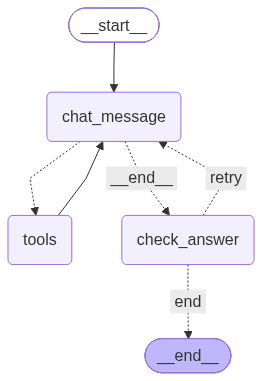

In [34]:
chat